In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
wine = load_wine()
x = wine.data
feature_names = wine.feature_names

df = pd.DataFrame(x, columns = feature_names)
print("Data shape :", df.shape)
print("First 5 row :", df.head())

Data shape : (178, 13)
First 5 row :    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted

In [7]:
selected_feature = ['alcohol', 'malic_acid']
x_selected = df[selected_feature].values

print("\n Selected Feature", selected_feature)


 Selected Feature ['alcohol', 'malic_acid']


In [8]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_selected)
print("Feature scaled.")

Feature scaled.


C:\Users\IT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\IT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\IT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\IT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

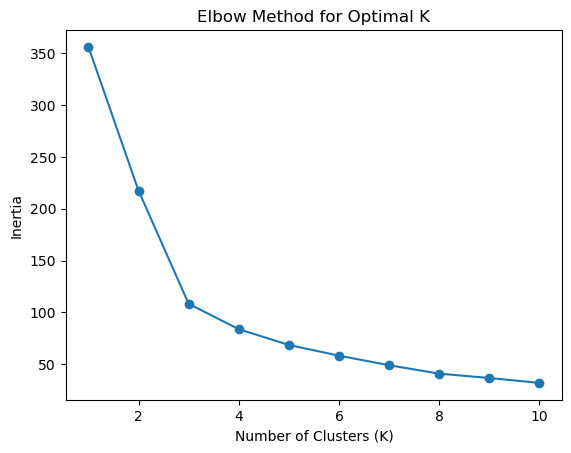

In [10]:

# ==========================================
# # 5. Finding Optimal Number of Clusters (Elbow Method)
# ==========================================
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot elbow curve
plt.figure()
plt.plot(K_range, inertia_values, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()


In [11]:
# ==========================================
# # 6. Train K-Means Model
# ==========================================
# Assume optimal clusters = 3 from elbow method
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_scaled)

# Add cluster labels
df['Cluster'] = clusters

print("\nCluster Centers (Scaled Values):")
print(kmeans.cluster_centers_)




Cluster Centers (Scaled Values):
[[-0.98858319 -0.5829103 ]
 [ 0.09906621  1.41480748]
 [ 0.87009843 -0.493973  ]]


C:\Users\IT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


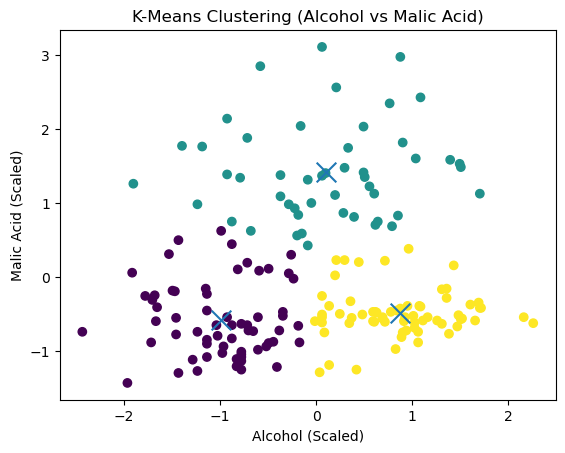

In [13]:
# ==========================================
# # 7. Visualizing Clusters
# ==========================================
plt.figure()

plt.scatter(
    x_scaled[:, 0],
    x_scaled[:, 1],
    c=clusters
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='x',
    s=200
)

plt.title("K-Means Clustering (Alcohol vs Malic Acid)")
plt.xlabel("Alcohol (Scaled)")
plt.ylabel("Malic Acid (Scaled)")
plt.show()

In [14]:
# ==========================================
# # 8. Evaluating Clustering Performance
# ==========================================
# Internal evaluation metric
sil_score = silhouette_score(x_scaled, clusters)

print("\nSilhouette Score:", sil_score)

"""
Interpretation:
- Value close to +1 -> good cluster separation
- Value near 0 -> overlapping clusters
- Negative value -> poor clustering
"""

# ==========================================
# # 9. Cluster Distribution
# ==========================================
print("\nNumber of samples in each cluster:")
print(df['Cluster'].value_counts())


Silhouette Score: 0.484095893654603

Number of samples in each cluster:
Cluster
2    66
0    63
1    49
Name: count, dtype: int64
